# 07 · Reaction type

What do we actually know about *reaction type* (e.g. "Suzuki coupling", "hydrogenation") in ORD? Three angles:

1. The user-submitted `REACTION_TYPE` reaction identifier -- free text, filled in by whoever curated the dataset.
2. A derived, model-based classification (Rxn-INSIGHT) that ord-schema briefly supported writing to `derived.reaction_classes`. That feature was removed from ord-schema upstream on 2026-08-18 ([PR #978](https://github.com/open-reaction-database/ord-schema/pull/978)), and **this database was never built with it** -- the query below returns empty here, but is written so it picks up real data automatically on a database that does have it.
3. A text-mining heuristic: dataset names/descriptions often name the reaction type even when no reaction in the dataset has a `REACTION_TYPE` tag. Tokenizing them gives a rough independent signal.

In [1]:
import re
from collections import Counter

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()
sns.set_theme(style="whitegrid")

## User-submitted `REACTION_TYPE`

`queries.user_reaction_types` reads `ReactionIdentifier` rows with `type == "REACTION_TYPE"`.

In [2]:
reaction_types = queries.user_reaction_types(engine)
total_reactions = queries.reaction_counts_by_dataset(engine)["count"].sum()
print(f"{len(reaction_types)} reactions with a REACTION_TYPE tag ({len(reaction_types) / total_reactions:.1%} of all {total_reactions} reactions)")
print(f"is_uspto breakdown:\n{reaction_types['is_uspto'].value_counts()}")
reaction_types["dataset_id"].value_counts().head(10)

115285 reactions with a REACTION_TYPE tag (4.7% of all 2428291 reactions)
is_uspto breakdown:
is_uspto
False    115285
Name: count, dtype: int64


dataset_id
ord_dataset-805ad863feef48579d95d86a728035f4    50688
ord_dataset-d92976309c3a48a3a64a4cf5e7048086    39347
ord_dataset-68cb8b4b2b384e3d85b5b1efae58b203     5760
ord_dataset-46ff9a32d9e04016b9380b1b1ef949c3     4312
ord_dataset-9b8aa9a7835143ef8ce3f70abfab7545     1762
ord_dataset-ac78456835404910b3a4c840248b6ac9     1728
ord_dataset-d26118acda314269becc35db5c22dc59     1728
ord_dataset-7d8f5fd922d4497d91cb81489b052746     1536
ord_dataset-3b8a2ef300e145468579027f206a3ac8     1440
ord_dataset-b440f8c90b6343189093770060fc4098     1152
Name: count, dtype: int64

`REACTION_TYPE` is free text, not a controlled vocabulary -- the same reaction type shows up under several different spellings/cases/phrasings.

In [3]:
reaction_types["value"].value_counts().head(20)

value
C–N coupling                     50688
Suzuki-Miyaura cross-coupling     5760
HYDROGENATION                     5503
SUZUKI                            4915
ALKYLATION                        4412
Buckwald-Hartwig amination        4312
BUCHWALD                          2992
CARBONYLATION                     2272
Imidazole Arylation               1984
CH ACTIVATION                     1916
Nano C-N                          1728
ULLMANN                           1718
LEWIS ACID                        1653
RH COUPLING                       1507
Suzuki                            1440
PD BORYLATION                     1165
PD COUPLING                       1159
Photodehalogenation               1152
reductive amination               1152
borylation                        1111
Name: count, dtype: int64

A best-effort normalization: case-fold, collapse whitespace, unify dash characters, then a small hand-built alias map for the duplicates visible above (this is illustrative, not exhaustive -- a real cleanup pass would need a much larger alias table or fuzzy matching).

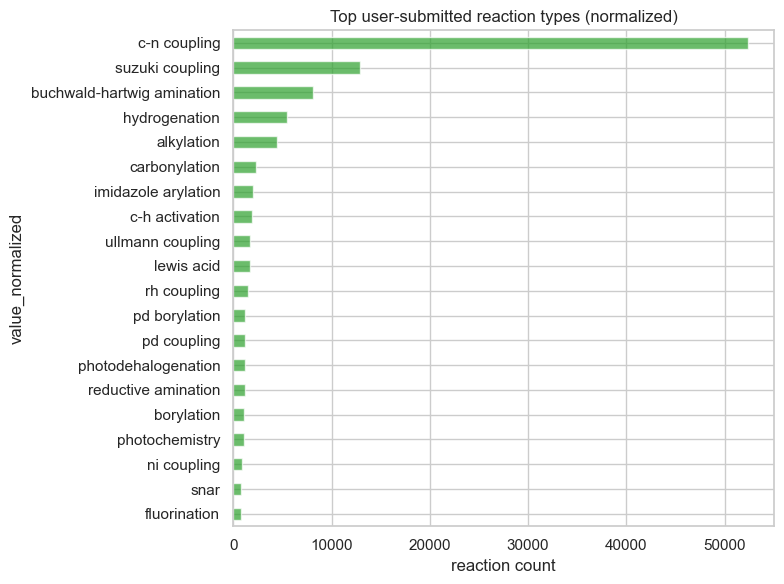

In [4]:
def normalize_reaction_type(value):
    text = value.strip().lower()
    text = text.replace("–", "-").replace("—", "-")  # en/em dash -> hyphen
    return re.sub(r"\s+", " ", text)

# Illustrative aliases for the duplicates visible in the top-20 above.
_REACTION_TYPE_ALIASES = {
    "suzuki": "suzuki coupling",
    "suzuki-miyaura cross-coupling": "suzuki coupling",
    "buchwald": "buchwald-hartwig amination",
    "buckwald-hartwig amination": "buchwald-hartwig amination",  # source typo
    "nano c-n": "c-n coupling",
    "ch activation": "c-h activation",
    "ullmann": "ullmann coupling",
}

reaction_types["value_normalized"] = reaction_types["value"].map(normalize_reaction_type)
reaction_types["value_normalized"] = reaction_types["value_normalized"].replace(_REACTION_TYPE_ALIASES)

fig, ax = plt.subplots(figsize=(8, 6))
reaction_types["value_normalized"].value_counts().head(20).sort_values().plot.barh(ax=ax, color="tab:green", alpha=0.7)
ax.set_title("Top user-submitted reaction types (normalized)")
ax.set_xlabel("reaction count")
plt.tight_layout()
plt.show()

## Derived (Rxn-INSIGHT) reaction classification

`queries.derived_reaction_classes` reads `derived.reaction_classes`, if it exists. This cell is written to run cleanly either way -- it prints a note and skips the chart when the table isn't present (as on this database), and produces the same chart as above when it is.

In [5]:
derived_classes = queries.derived_reaction_classes(engine)

if derived_classes.empty:
    print("No `derived.reaction_classes` table on this database -- nothing to show yet.")
else:
    print(f"{len(derived_classes)} reactions with a derived classification")
    n_classified = derived_classes["reaction_class"].notna().sum()
    print(f"{n_classified} / {len(derived_classes)} rows have a non-null reaction_class")

    fig, ax = plt.subplots(figsize=(8, 6))
    derived_classes["reaction_class"].value_counts().head(20).sort_values().plot.barh(
        ax=ax, color="tab:orange", alpha=0.7
    )
    ax.set_title("Top Rxn-INSIGHT reaction classes")
    ax.set_xlabel("reaction count")
    plt.tight_layout()
    plt.show()

No `derived.reaction_classes` table on this database -- nothing to show yet.


## Dataset name/description tokenization

An independent, dataset-level signal: what words show up in dataset names/descriptions? Two views -- how many *datasets* mention a word, and how many *reactions* sit in datasets that mention it (a word coined by one giant dataset should count for more than one coined by a 96-reaction dataset).

In [6]:
_STOPWORDS = {
    "a", "an", "the", "and", "or", "of", "in", "on", "for", "to", "with", "from", "by", "at", "as",
    "is", "are", "was", "were", "be", "been", "this", "that", "these", "those", "it", "its", "into",
    "using", "used", "via", "based", "et", "al", "www", "com", "org", "https", "http", "doi",
    "dataset", "datasets", "data", "reaction", "reactions", "chemistry", "chemical", "compound", "compounds",
    "figure", "which", "publication", "here", "present", "originally",
}


def tokenize(text):
    if not isinstance(text, str):
        return []
    words = re.findall(r"[a-z][a-z\-]{2,}", text.lower())
    return [w for w in words if w not in _STOPWORDS]


datasets = queries.dataset_overview(engine)
datasets["text"] = datasets["name"].fillna("") + " " + datasets["description"].fillna("")
datasets["tokens"] = datasets["text"].map(tokenize)
datasets[["dataset_id", "tokens"]].head()

,dataset_id,tokens
0,ord_dataset-0316886541d9435489859c2ad7edc863,"[styrene, mizoroki-heck, mizoroki-heck, coupli..."
1,ord_dataset-10b940e7982c4622b1e1ac879394aba6,"[imidazopyridines, form, component, approach, ..."
2,ord_dataset-0c75d67751634f0594b24b9f498b77c2,"[shields, arylation, shields, stevens, bayesia..."
3,ord_dataset-00005539a1e04c809a9a78647bea649c,"[astrazeneca, eln, includes, buchwald-hartwig,..."
4,ord_dataset-172039a759a440219a68af62d203b79b,"[cernak, miniaturized, n-alkylation, boc, depr..."


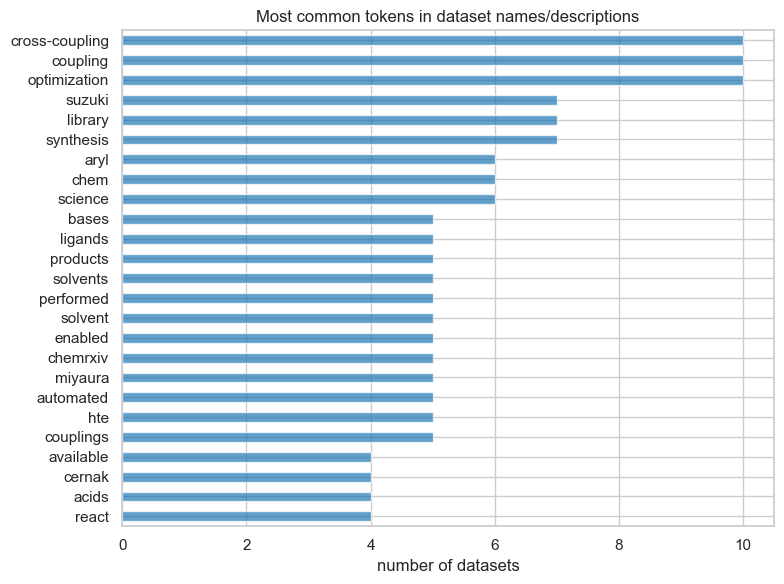

In [7]:
dataset_token_counts = Counter()
for tokens in datasets["tokens"]:
    dataset_token_counts.update(set(tokens))

top_tokens = pd.Series(dataset_token_counts).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 6))
top_tokens.sort_values().plot.barh(ax=ax, color="tab:blue", alpha=0.7)
ax.set_title("Most common tokens in dataset names/descriptions")
ax.set_xlabel("number of datasets")
plt.tight_layout()
plt.show()

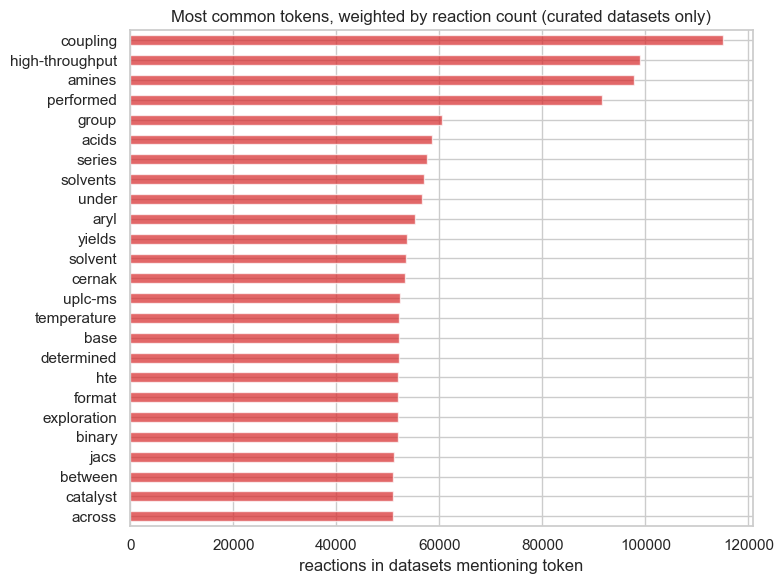

In [8]:
counts = queries.reaction_counts_by_dataset(engine)
dataset_totals = counts.groupby("dataset_id")["count"].sum()
# DOI-based, matching `is_uspto` everywhere else in this repo -- `dataset_overview`'s own
# is_uspto (a name-substring match) misses 3 of the 4 USPTO-mined dataset_ids here.
uspto_dataset_ids = set(counts.loc[counts["is_uspto"], "dataset_id"])

# Restricted to curated datasets: the USPTO-mined datasets are ~1.7-1.8M reactions each and
# their descriptions are boilerplate provenance text ("consolidated from monthly USPTO grants...")
# that completely swamps any real reaction-type signal -- and we already know from the
# REACTION_TYPE analysis above that they carry no reaction-type tags anyway.
curated = datasets[~datasets["dataset_id"].isin(uspto_dataset_ids)]

weighted_token_counts = Counter()
for _, row in curated.iterrows():
    n = dataset_totals.get(row["dataset_id"], 0)
    for token in set(row["tokens"]):
        weighted_token_counts[token] += n

top_weighted = pd.Series(weighted_token_counts).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 6))
top_weighted.sort_values().plot.barh(ax=ax, color="tab:red", alpha=0.7)
ax.set_title("Most common tokens, weighted by reaction count (curated datasets only)")
ax.set_xlabel("reactions in datasets mentioning token")
plt.tight_layout()
plt.show()